<a href="https://colab.research.google.com/github/johnff9/CSB410_Project1/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1

### Loading the Data:


Training samples: 60000
Test samples: 10000
Image shape: 28x28
Label encoding: One-hot (shape: (60000, 10))

Class Distribution:
  0 (Tshirt/top     ):  6000 samples (10.0%)
  1 (Trouser        ):  6000 samples (10.0%)
  2 (Pullover       ):  6000 samples (10.0%)
  3 (Dress          ):  6000 samples (10.0%)
  4 (Coat           ):  6000 samples (10.0%)
  5 (Sandal         ):  6000 samples (10.0%)
  6 (Shirt          ):  6000 samples (10.0%)
  7 (Sneaker        ):  6000 samples (10.0%)
  8 (Bag            ):  6000 samples (10.0%)
  9 (Ankle boot     ):  6000 samples (10.0%)

Observations:
  - Dataset is BALANCED: ~6,000 samples per class
  - 10 clothing categories with clear visual distinctions
  - Images are 28×28 grayscale pixels


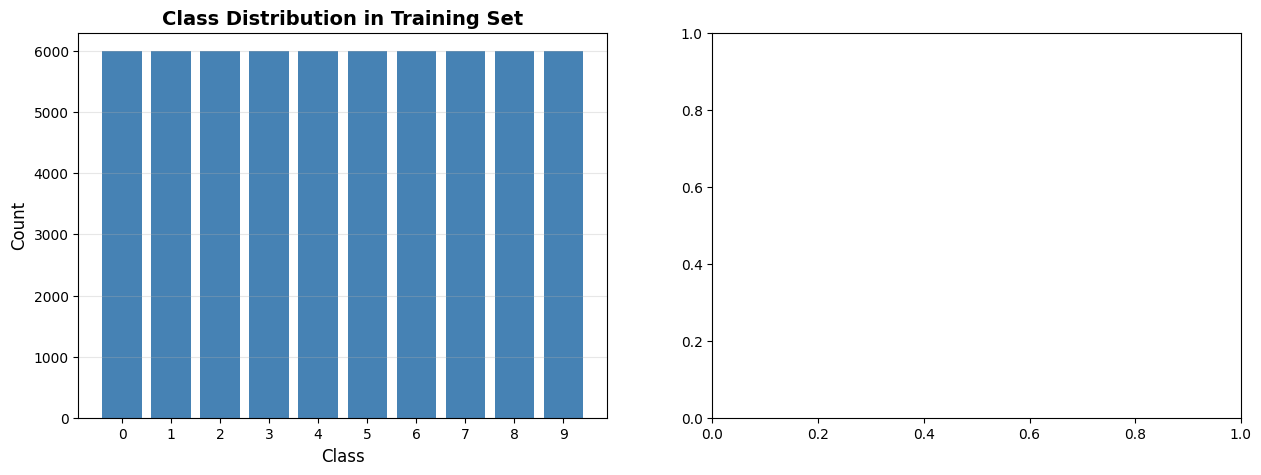

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, classification_report


# 1. DATA LOADING AND EXPLORATION

# Load data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape for dense networks (flatten)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

# Convert labels to one-hot encoding for categorical_crossentropy
y_train_categorical = keras.utils.to_categorical(y_train, 10)
y_test_categorical = keras.utils.to_categorical(y_test, 10)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"Label encoding: One-hot (shape: {y_train_categorical.shape})")


# 2. DATA EXPLORATION

# Class names
CLASS_NAMES = ['Tshirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("\nClass Distribution:")
for class_id, count in class_distribution.items():
    percentage = (count / len(y_train)) * 100
    print(f"  {class_id} ({CLASS_NAMES[class_id]:15s}): {count:5d} samples ({percentage:.1f}%)")

print("\nObservations:")
print("  - Dataset is BALANCED: ~6,000 samples per class")
print("  - 10 clothing categories with clear visual distinctions")
print("  - Images are 28×28 grayscale pixels")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
axes[0].bar(range(10), [class_distribution[i] for i in range(10)], color='steelblue')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(range(10))
axes[0].grid(axis='y', alpha=0.3)

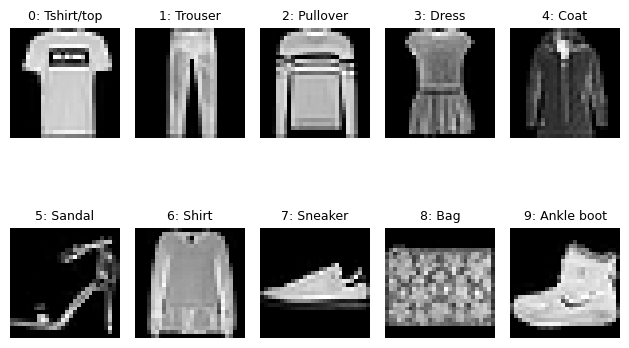

In [4]:
# Sample images
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"{i}: {CLASS_NAMES[i]}", fontsize=9)
    plt.axis('off')

plt.tight_layout()

## Training the Model

In [5]:
# 3. MODEL PREPARATION


# Model configurations
MODEL_CONFIGS = [
    # Shallow: 1-2 hidden layers, 32-128 neurons
    {
        'id': 'shallow_relu',
        'name': 'Shallow + ReLU',
        'activation': 'relu',
        'layers': [128, 64],
        'color': '#ef4444'
    },
    {
        'id': 'shallow_sigmoid',
        'name': 'Shallow + Sigmoid',
        'activation': 'sigmoid',
        'layers': [128, 64],
        'color': '#f97316'
    },
    {
        'id': 'shallow_tanh',
        'name': 'Shallow + Tanh',
        'activation': 'tanh',
        'layers': [128, 64],
        'color': '#eab308'
    },
    # Deep: 3-4 hidden layers, 64-512 neurons
    {
        'id': 'deep_relu',
        'name': 'Deep + ReLU',
        'activation': 'relu',
        'layers': [256, 128, 128, 64],
        'color': '#22c55e'
    },
    {
        'id': 'deep_sigmoid',
        'name': 'Deep + Sigmoid',
        'activation': 'sigmoid',
        'layers': [256, 128, 128, 64],
        'color': '#3b82f6'
    },
    {
        'id': 'deep_tanh',
        'name': 'Deep + Tanh',
        'activation': 'tanh',
        'layers': [256, 128, 128, 64],
        'color': '#8b5cf6'
    }
]


def build_model(config):
    model = models.Sequential(name=config['id'])

    # Input layer
    model.add(layers.Input(shape=(784,)))

    # Hidden layers with regularization
    for i, units in enumerate(config['layers']):
        model.add(layers.Dense(
            units,
            activation=config['activation'],
            kernel_regularizer=keras.regularizers.l2(0.001)
        ))
        model.add(layers.BatchNormalization())

        # Add dropout to all hidden layers
        model.add(layers.Dropout(0.2))

    # Output layer
    model.add(layers.Dense(10, activation='softmax'))

    # Compile model with better learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model




# Training configuration
EPOCHS = 10  # Increased from 5 for better convergence
BATCH_SIZE = 128
VALIDATION_SPLIT = 0.2

# Store results
results = {}

# Train all models
for config in MODEL_CONFIGS:
    print(f"\n{'='*70}")
    print(f"Training: {config['name']}")
    print(f"{'='*70}")

    # Build model
    model = build_model(config)

    # The below learning rate reduction callback and the early stopping are both created using AI in an attempted to improve the accruacy of the models
    # Add learning rate reduction callback
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=1
    )

    # Early stopping to prevent overfitting
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    # Train model
    history = model.fit(
        X_train_flat, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=[reduce_lr, early_stop],
        verbose=1
    )

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)

    # Get predictions for confusion matrix
    y_pred_probs = model.predict(X_test_flat, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Classification report
    report = classification_report(
        y_test, y_pred,
        target_names=CLASS_NAMES,  # Add target_names here
        output_dict=True
    )

    # Store results
    results[config['id']] = {
        'config': config,
        'history': history.history,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'confusion_matrix': cm,
        'classification_report': report,
        'y_pred': y_pred
    }

    print(f"\n✓ Test Loss: {test_loss:.4f}")
    print(f"✓ Test Accuracy: {test_accuracy*100:.2f}%")


Training: Shallow + ReLU
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7200 - loss: 1.1037 - val_accuracy: 0.8435 - val_loss: 0.6790 - learning_rate: 0.0010
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8361 - loss: 0.6614 - val_accuracy: 0.8396 - val_loss: 0.6112 - learning_rate: 0.0010
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8466 - loss: 0.5781 - val_accuracy: 0.8436 - val_loss: 0.5517 - learning_rate: 0.0010
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8558 - loss: 0.5276 - val_accuracy: 0.8367 - val_loss: 0.5531 - learning_rate: 0.0010
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8553 - loss: 0.5067 - val_accuracy: 0.8394 - val_loss: 0.5360 - learning_rate: 0.0010
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8619 - loss: 0.4765 - val_accuracy: 0.8593 - val_loss: 0.4757 - learning_rate: 0.0010
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accurac

## Evaluation


GENERATING VISUALIZATIONS

✓ Saved: 2_training_curves_all_models.png


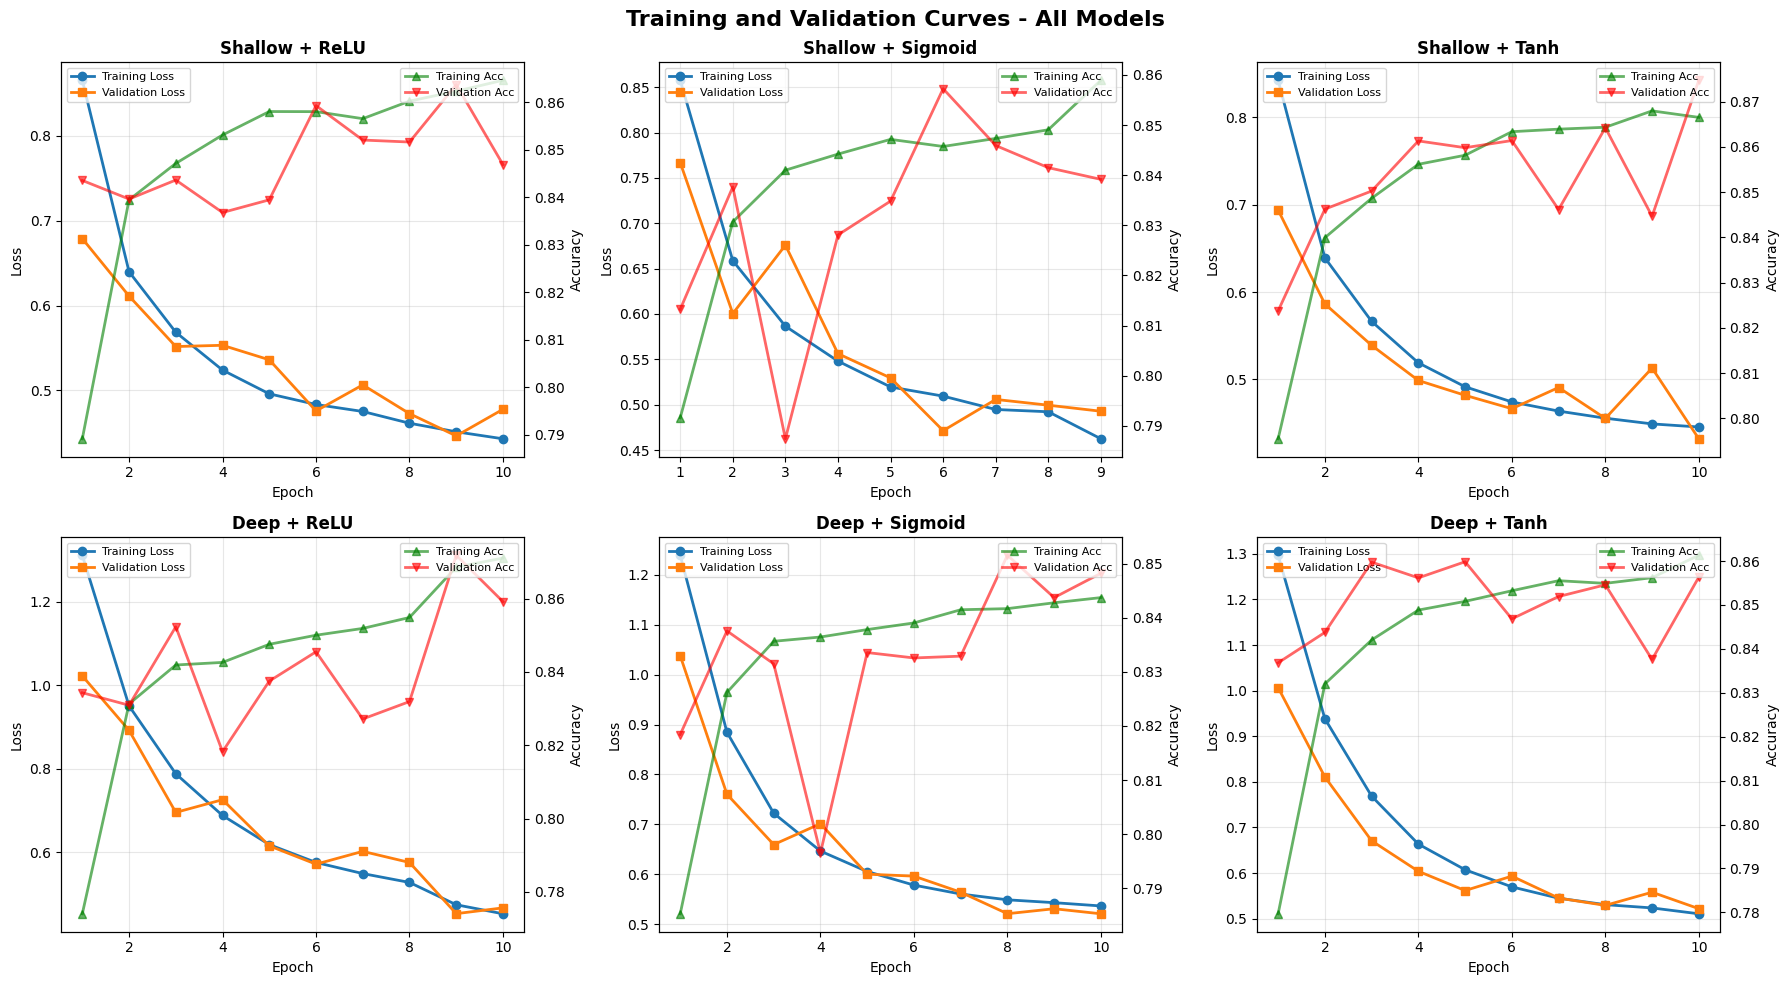

In [6]:
# 5. VISUALIZATION - TRAINING CURVES - All plots where made with the help of AI

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# Class names
CLASS_NAMES = ['Tshirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot training curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training and Validation Curves - All Models', fontsize=16, fontweight='bold')

for idx, config in enumerate(MODEL_CONFIGS):
    result = results[config['id']]
    history = result['history']

    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    actual_epochs = len(history['loss'])
    epochs_range = range(1, actual_epochs + 1)

    # Plot loss
    ax.plot(epochs_range, history['loss'], 'o-', label='Training Loss', linewidth=2)
    ax.plot(epochs_range, history['val_loss'], 's-', label='Validation Loss', linewidth=2)

    # Plot accuracy on secondary axis
    ax2 = ax.twinx()
    ax2.plot(epochs_range, history['accuracy'], '^-', label='Training Acc',
             linewidth=2, color='green', alpha=0.6)
    ax2.plot(epochs_range, history['val_accuracy'], 'v-', label='Validation Acc',
             linewidth=2, color='red', alpha=0.6)

    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax2.set_ylabel('Accuracy', fontsize=10)
    ax.set_title(config['name'], fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('2_training_curves_all_models.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: 2_training_curves_all_models.png")

✓ Saved: 3_loss_comparison.png
✓ Saved: 4_accuracy_comparison.png


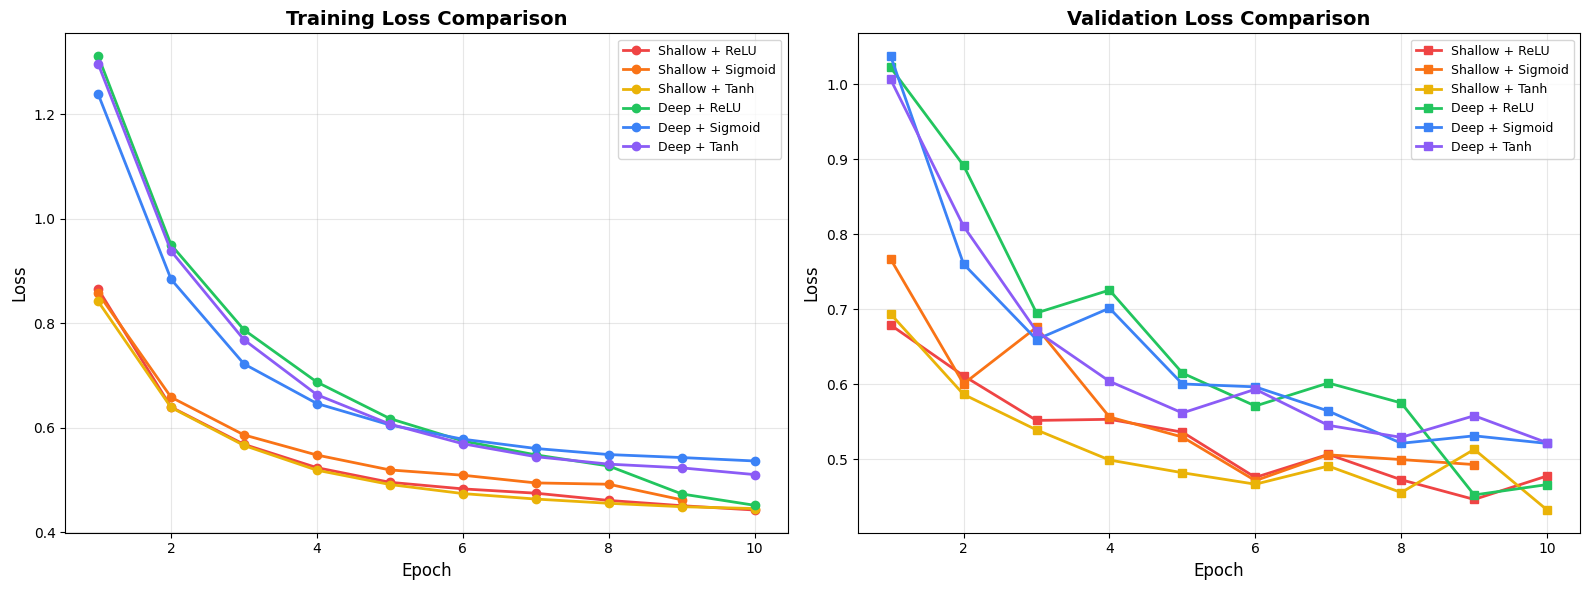

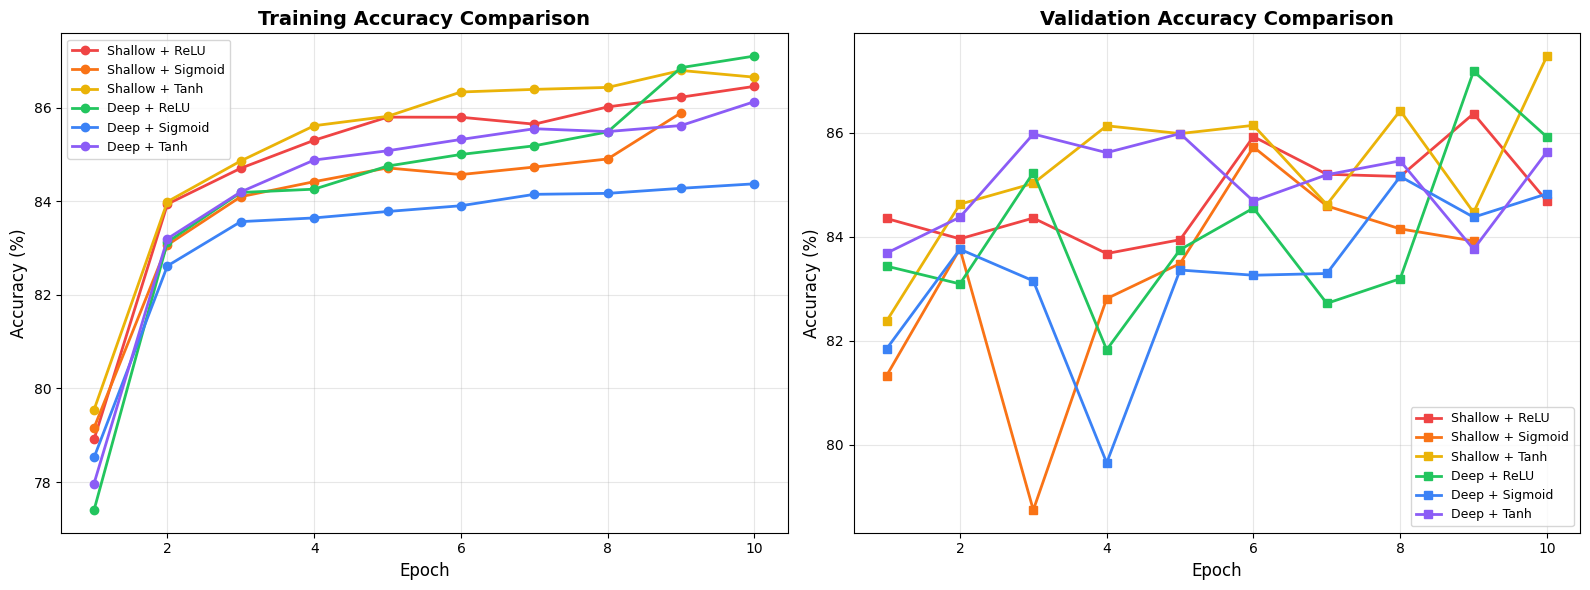

In [7]:
# 6. COMPARISON PLOTS

# Loss comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for config in MODEL_CONFIGS:
    result = results[config['id']]
    history = result['history']
    actual_epochs = len(history['loss'])
    epochs_range = range(1, actual_epochs + 1)

    ax1.plot(epochs_range, history['loss'], 'o-',
             label=config['name'], color=config['color'], linewidth=2)
    ax2.plot(epochs_range, history['val_loss'], 's-',
             label=config['name'], color=config['color'], linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3_loss_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 3_loss_comparison.png")

# Accuracy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for config in MODEL_CONFIGS:
    result = results[config['id']]
    history = result['history']
    actual_epochs = len(history['accuracy'])
    epochs_range = range(1, actual_epochs + 1)

    ax1.plot(epochs_range, [acc*100 for acc in history['accuracy']], 'o-',
             label=config['name'], color=config['color'], linewidth=2)
    ax2.plot(epochs_range, [acc*100 for acc in history['val_accuracy']], 's-',
             label=config['name'], color=config['color'], linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('4_accuracy_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 4_accuracy_comparison.png")

✓ Saved: 5_test_performance.png


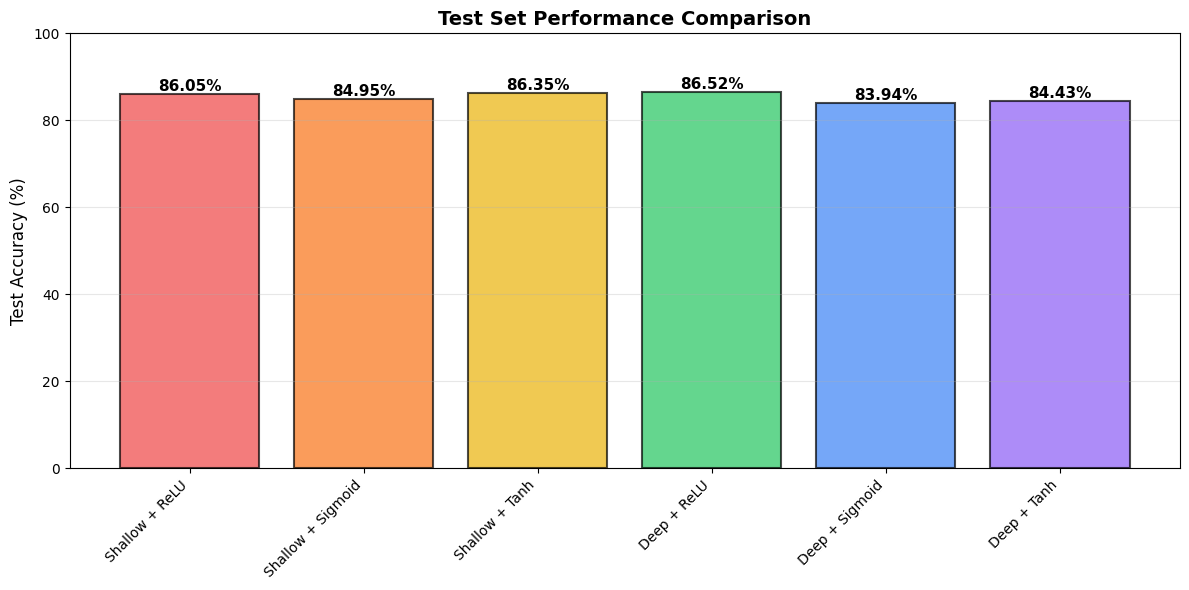

In [8]:
# 7. TEST SET PERFORMANCE

# Bar chart of test accuracies
fig, ax = plt.subplots(figsize=(12, 6))

model_names = [config['name'] for config in MODEL_CONFIGS]
test_accs = [results[config['id']]['test_accuracy'] * 100 for config in MODEL_CONFIGS]
colors = [config['color'] for config in MODEL_CONFIGS]

bars = ax.bar(model_names, test_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, test_accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Test Set Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('5_test_performance.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 5_test_performance.png")

✓ Saved: 6_confusion_matrices.png


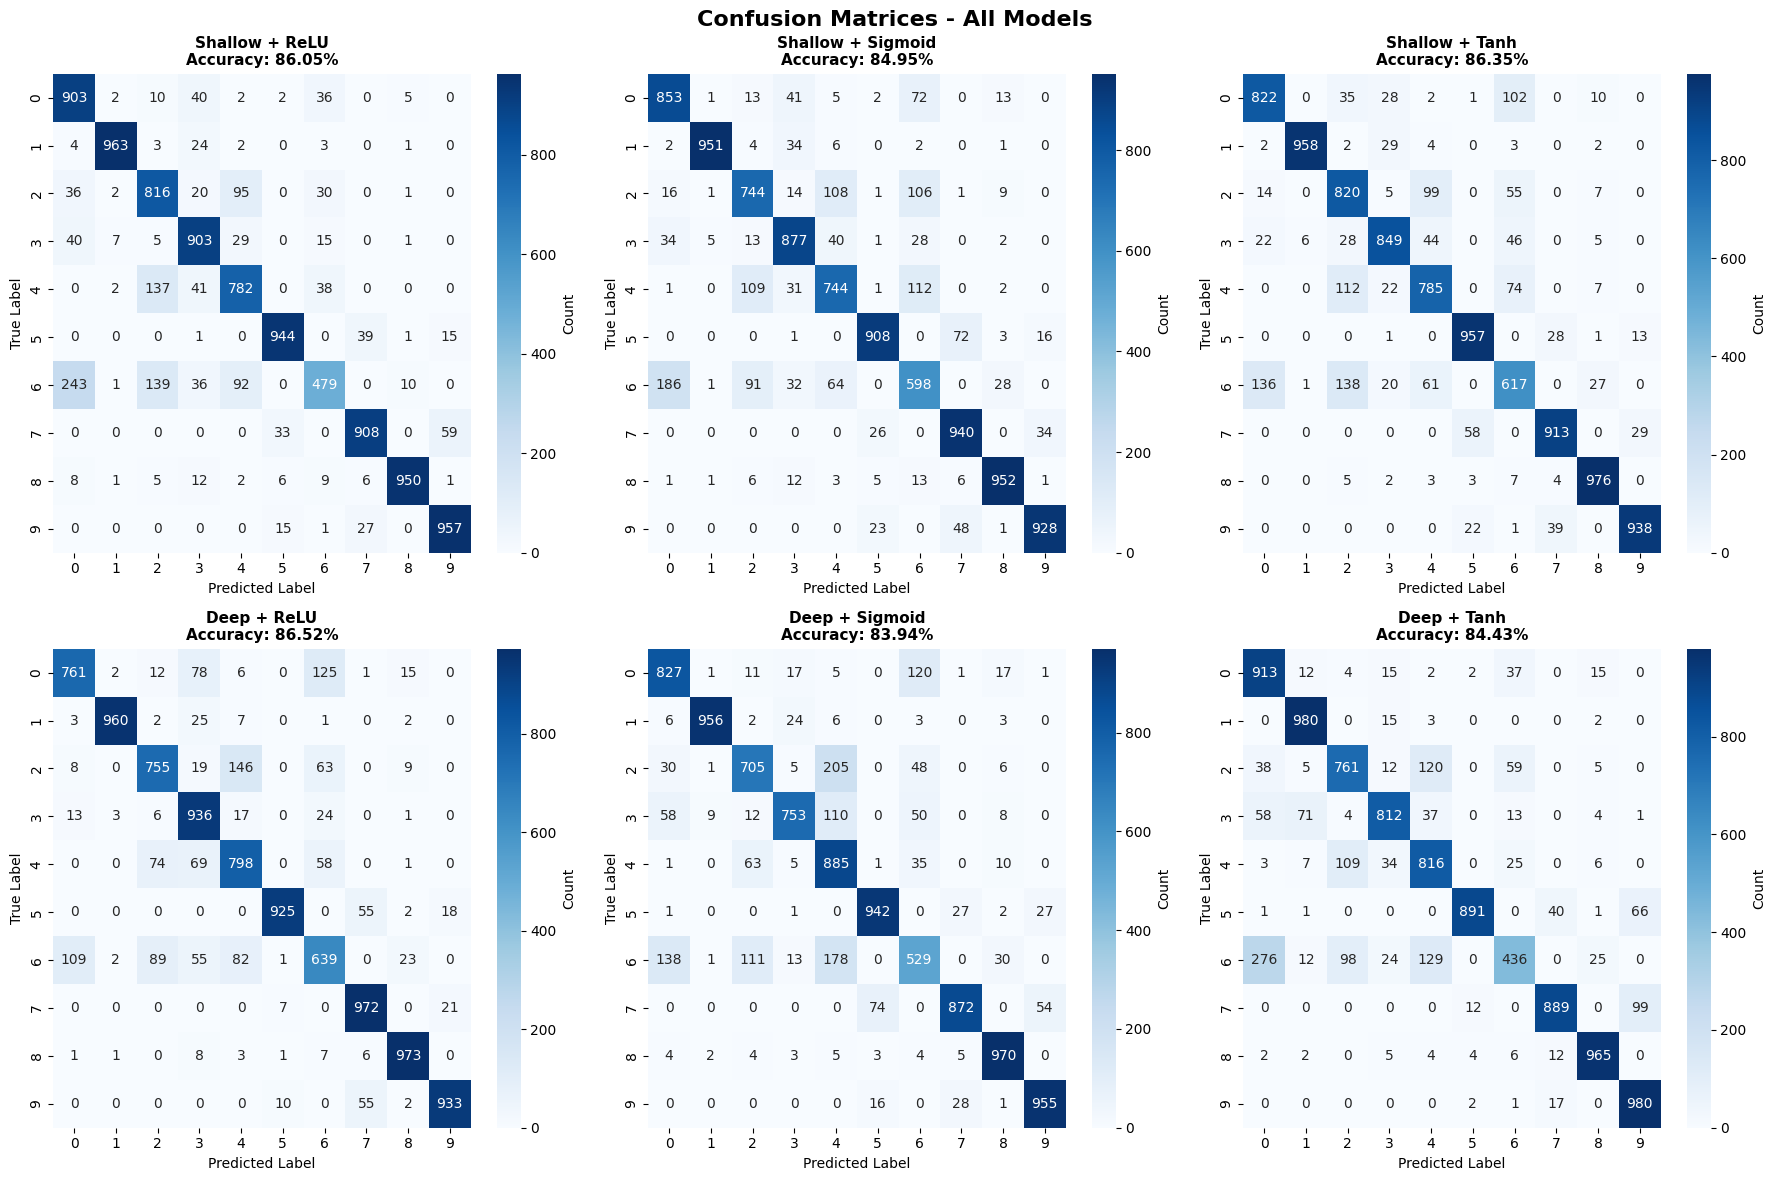

In [9]:
# 8. CONFUSION MATRICES

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

for idx, config in enumerate(MODEL_CONFIGS):
    result = results[config['id']]
    cm = result['confusion_matrix']

    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10),
                cbar_kws={'label': 'Count'})

    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(f"{config['name']}\nAccuracy: {result['test_accuracy']*100:.2f}%",
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('6_confusion_matrices.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 6_confusion_matrices.png")

In [10]:
# 9. CLASSIFICATION REPORTS

print("\n" + "="*70)
print("CLASSIFICATION REPORTS")
print("="*70)

for config in MODEL_CONFIGS:
    result = results[config['id']]
    report = result['classification_report']

    print(f"\n{'='*70}")
    print(f"{config['name']} - Test Accuracy: {result['test_accuracy']*100:.2f}%")
    print(f"{'='*70}")

    print(f"\n{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 70)

    for class_name in CLASS_NAMES:
        metrics = report[class_name]
        print(f"{class_name:<15} {metrics['precision']:<12.3f} {metrics['recall']:<12.3f} "
              f"{metrics['f1-score']:<12.3f} {int(metrics['support']):<10}")

    print("-" * 70)
    print(f"{'Accuracy':<15} {'':<12} {'':<12} {report['accuracy']:<12.3f} "
          f"{int(report['macro avg']['support']):<10}")
    print(f"{'Macro Avg':<15} {report['macro avg']['precision']:<12.3f} "
          f"{report['macro avg']['recall']:<12.3f} {report['macro avg']['f1-score']:<12.3f} "
          f"{int(report['macro avg']['support']):<10}")
    print(f"{'Weighted Avg':<15} {report['weighted avg']['precision']:<12.3f} "
          f"{report['weighted avg']['recall']:<12.3f} {report['weighted avg']['f1-score']:<12.3f} "
          f"{int(report['weighted avg']['support']):<10}")


CLASSIFICATION REPORTS

Shallow + ReLU - Test Accuracy: 86.05%

Class           Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Tshirt/top      0.732        0.903        0.808        1000      
Trouser         0.985        0.963        0.974        1000      
Pullover        0.732        0.816        0.772        1000      
Dress           0.838        0.903        0.870        1000      
Coat            0.779        0.782        0.780        1000      
Sandal          0.944        0.944        0.944        1000      
Shirt           0.784        0.479        0.595        1000      
Sneaker         0.927        0.908        0.917        1000      
Bag             0.980        0.950        0.965        1000      
Ankle boot      0.927        0.957        0.942        1000      
----------------------------------------------------------------------
Accuracy                                  0.861        10000     
M

In [11]:
# 10. SUMMARY AND RECOMMENDATIONS

print("\n" + "="*70)
print("SUMMARY AND RECOMMENDATIONS")
print("="*70)

# Find best model
best_model_id = max(results.keys(), key=lambda k: results[k]['test_accuracy'])
best_model = results[best_model_id]
best_config = best_model['config']

print(f"\n BEST MODEL: {best_config['name']}")
print(f"   Test Accuracy: {best_model['test_accuracy']*100:.2f}%")
print(f"   Architecture: {' → '.join(map(str, best_config['layers']))}")
print(f"   Activation: {best_config['activation'].upper()}")

print("\n RANKING:")
sorted_models = sorted(
    [(config, results[config['id']]['test_accuracy']) for config in MODEL_CONFIGS],
    key=lambda x: x[1], reverse=True
)

for rank, (config, accuracy) in enumerate(sorted_models, 1):
    print(f"   {rank}. {config['name']:<25} {accuracy*100:.2f}%")

print("\n KEY FINDINGS:")
print("\n   Activation Functions:")
print("   • ReLU: Fast convergence, avoids vanishing gradients")
print("   • Sigmoid: May struggle in deep networks due to vanishing gradients")
print("   • Tanh: Zero-centered, often better than sigmoid for hidden layers")

print("\n   Architecture Depth:")
print("   • Shallow : Faster training, may underfit complex patterns")
print("   • Deep : More capacity, better feature extraction")

print("\n   Regularization:")
print("   • Dropout (0.3) helps prevent overfitting")
print("   • Batch Normalization stabilizes training across all activations")

print("\n Improvements:")
print("   • For Fashion MNIST: Deep architectures with ReLU typically perform best")
print("   • Use BatchNormalization for training stability")
print("   • Dropout rate of 0.3 provides good regularization")
print("   • Consider increasing epochs to 10-20 for better convergence")
print("   • Adam optimizer with lr=0.001 works well across all models")


SUMMARY AND RECOMMENDATIONS

 BEST MODEL: Deep + ReLU
   Test Accuracy: 86.52%
   Architecture: 256 → 128 → 128 → 64
   Activation: RELU

 RANKING:
   1. Deep + ReLU               86.52%
   2. Shallow + Tanh            86.35%
   3. Shallow + ReLU            86.05%
   4. Shallow + Sigmoid         84.95%
   5. Deep + Tanh               84.43%
   6. Deep + Sigmoid            83.94%

 KEY FINDINGS:

   Activation Functions:
   • ReLU: Fast convergence, avoids vanishing gradients
   • Sigmoid: May struggle in deep networks due to vanishing gradients
   • Tanh: Zero-centered, often better than sigmoid for hidden layers

   Architecture Depth:
   • Shallow : Faster training, may underfit complex patterns
   • Deep : More capacity, better feature extraction

   Regularization:
   • Dropout (0.3) helps prevent overfitting
   • Batch Normalization stabilizes training across all activations

 Improvements:
   • For Fashion MNIST: Deep architectures with ReLU typically perform best
   • Use Batch

**1. Which architecture model template with a specific activation function performed better? Why?**

The Deep + ReLU model performed the best with a test accuracy of 86.51%.

Deep architectures generally have more capacity to learn complex visual patterns in the data compared to shallow ones. The ReLU activation function is often preferred in deep networks because it helps mitigate the vanishing gradient problem, allowing for more effective training. The combination of a deeper network and the efficient ReLU activation likely contributed to its superior performance on this dataset.


**2. What did the evaluation metrics tell you that accuracy did not?**

While accuracy provides an overall measure of correct predictions, the classification report and confusion matrix provide a more detailed understanding of the model's performance for each class:

Classification Report (Precision, Recall, F1-Score): The classification report shows the precision, recall, and F1-score for each individual class.
Precision: Tells you how many of the items the model predicted as a certain class actually belong to that class. Low precision for a class means the model is frequently making false positive predictions for that class.
Recall: Tells you how many of the actual items belonging to a certain class the model correctly identified. Low recall for a class means the model is missing a significant number of instances of that class has high false negatives.

Confusion Matrix: This visual tool shows a table where each row represents the true class and each column represents the predicted class. The diagonal elements show the number of correct predictions for each class, while the off-diagonal elements show the misclassifications between different classes. The confusion matrix directly reveals which classes are being confused with each other.

**3. How would you improve your models?**

More Complex Architectures: While the Deep + ReLU model performed best among the tested configurations, exploring even deeper or more complex architectures like Convolutional Neural Networks (CNNs) would likely yield better results for image data. CNNs are specifically designed to handle spatial hierarchies in images and have shown state-of-the-art performance on image classification tasks.

More Data or Data Augmentation: Although the Fashion MNIST dataset is relatively large, increasing the amount of training data or using data augmentation techniques (like random rotations, shifts, or zooms) could help the model generalize better and reduce overfitting.

Different Optimizers: Experimenting with other optimizers like SGD with momentum, Adagrad, or Adadelta might lead to faster convergence or better final performance.

Adjusting Regularization: The current dropout rate is 0.2. Experimenting with slightly higher or lower dropout rates, or using different regularization techniques, could help find a better balance between fitting the training data and generalizing to unseen data.

Longer Training: Increasing the number of epochs beyond 10, while monitoring validation loss for early stopping, might allow the models to converge further and potentially achieve higher accuracy.

**4. What are some potential ethical risks or limitations of using deep learning for image classification tasks like this one?**


Bias in Data: If the Fashion MNIST dataset is not representative of the real-world distribution of clothing styles, body types, or demographics, the trained model may exhibit bias. For example, it might perform poorly on clothing items or styles that are less represented in the training data, leading to unfair outcomes if used in applications like personalized recommendations or automated inventory management.

Lack of Transparency and Explainability (Black Box): Deep learning models, especially complex ones, can be considered black boxes. It's often difficult to understand why a model makes a particular prediction. In applications where decisions have significant consequences this lack of explainability can be a major ethical concern, as it's hard to trust or debug the model's reasoning.

Privacy Concerns: If the model is trained on images containing identifiable information, there are privacy risks associated with the data itself and how the model might inadvertently reveal information about individuals.

Environmental Impact: Training large deep learning models can be computationally intensive and consume significant amounts of energy, contributing to carbon emissions.